In [3]:
import pandas as pd

df = pd.read_csv("../data/boids_20260420_101635.csv")

df["CompletionRate"] = df["Finished"] / df["Spawned"]

pd.set_option("display.max_columns", None)

df.style.format({
    "MeanTransit": "{:.2f}",
    "Throughput": "{:.2f}",
    "CompletionRate": "{:.3f}"
})

df

,Iteration,wSeparation,wAlignment,wCohesion,wWaypoint,s_wSeparation,s_wAlignment,s_wCohesion,s_wWaypoint,SecondaryFraction,MeanTransit,Throughput,TotalCollisions,BoidBoidCollisions,BoidWallCollisions,Finished,Spawned,CompletionRate
0,1,2,1,0.5,2,5,1,0.5,2,0,60.039,5.000,790,790,0,499,500,0.998
1,2,2,1,0.5,2,5,1,0.5,2,0,59.606,6.106,774,774,0,500,500,1.000


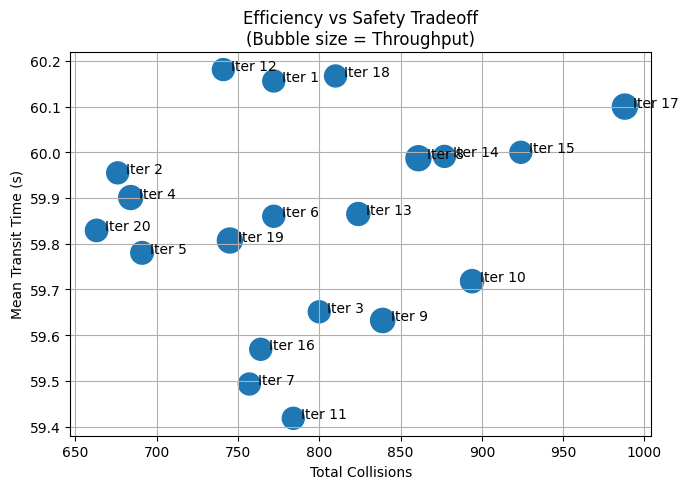

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/boids_20260420_101635.csv")

# Derived metric
df["CompletionRate"] = df["Finished"] / df["Spawned"]

plt.figure(figsize=(7,5))

scatter = plt.scatter(
    df["TotalCollisions"],
    df["MeanTransit"],
    s=df["Throughput"] * 50,   # bubble size = throughput
)

for i, row in df.iterrows():
    plt.text(row["TotalCollisions"] + 5, row["MeanTransit"], f"Iter {int(row['Iteration'])}")

plt.xlabel("Total Collisions")
plt.ylabel("Mean Transit Time (s)")
plt.title("Efficiency vs Safety Tradeoff\n(Bubble size = Throughput)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

df = pd.read_csv("../data/boids_20260409_151235.csv")

df["CompletionRate"] = df["Finished"] / df["Spawned"]

# Group by configuration (primary + secondary weights)
grouped = df.groupby([
    "wSeparation",
    "wAlignment",
    "wCohesion",
    "s_wSeparation",
    "s_wAlignment",
    "s_wCohesion",
    "SecondaryFraction"
]).mean(numeric_only=True).reset_index()

grouped

,wSeparation,wAlignment,wCohesion,s_wSeparation,s_wAlignment,s_wCohesion,SecondaryFraction,Iteration,wWaypoint,s_wWaypoint,MeanTransit,Throughput,TotalCollisions,BoidBoidCollisions,BoidWallCollisions,Finished,Spawned,CompletionRate
0,2,1,0.5,5,1,0.5,0,1.5,2.0,2.0,59.8225,5.553,782.0,782.0,0.0,499.5,500.0,0.999


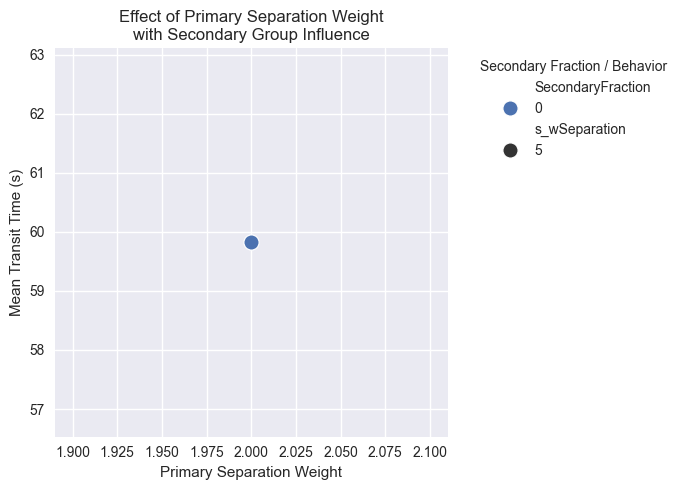

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=grouped,
    x="wSeparation",
    y="MeanTransit",
    hue="SecondaryFraction",        # color = % secondary agents
    style="s_wSeparation",          # marker = secondary behaviour
    s=120
)

plt.xlabel("Primary Separation Weight")
plt.ylabel("Mean Transit Time (s)")
plt.title("Effect of Primary Separation Weight\nwith Secondary Group Influence")

plt.legend(title="Secondary Fraction / Behavior", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.show()

In [10]:
import pandas as pd
from pathlib import Path

data_path = Path("../data")

files = {
    "Baseline": "boids_20260420_Base.csv",
    "Individualist": "boids_20260420_Indu.csv",
    "Clinger": "boids_20260420_Cling.csv",
    "Eccentric": "boids_20260420_Exa.csv"
}

dfs = []

for label, file in files.items():
    df = pd.read_csv(data_path / file)
    df["Behavior"] = label
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Derived metric
df_all["CompletionRate"] = df_all["Finished"] / df_all["Spawned"]

In [11]:
table = df_all.groupby("Behavior")[[
    "MeanTransit",
    "TotalCollisions",
    "Throughput",
    "CompletionRate"
]].mean().reset_index()

# Round nicely
table = table.round({
    "MeanTransit": 2,
    "TotalCollisions": 0,
    "Throughput": 2,
    "CompletionRate": 3
})

table

,Behavior,MeanTransit,TotalCollisions,Throughput,CompletionRate
0,Baseline,59.85,793.0,5.40,0.998
1,Clinger,60.23,1568.0,5.76,0.999
2,Eccentric,63.61,606.0,5.00,0.980
3,Individualist,64.35,295.0,5.00,0.964


In [12]:
import pandas as pd
from pathlib import Path

data_path = Path("../data")

files = {
    "Baseline": "boids_20260420_Base.csv",
    "Individualist": "boids_20260420_Indu.csv",
    "Clinger": "boids_20260420_Cling.csv",
    "Eccentric": "boids_20260420_Exa.csv"
}

rows = []

for label, file in files.items():
    df = pd.read_csv(data_path / file)

    # Take first row (same config for all rows)
    row = df.iloc[0]

    if label == "Baseline":
        # Use primary weights
        rows.append({
            "Behavior": label,
            "Separation": row["wSeparation"],
            "Alignment": row["wAlignment"],
            "Cohesion": row["wCohesion"],
            "Waypoint": row["wWaypoint"]
        })
    else:
        # Use secondary weights
        rows.append({
            "Behavior": label,
            "Separation": row["s_wSeparation"],
            "Alignment": row["s_wAlignment"],
            "Cohesion": row["s_wCohesion"],
            "Waypoint": row["s_wWaypoint"]
        })

config_table = pd.DataFrame(rows)

config_table

,Behavior,Separation,Alignment,Cohesion,Waypoint
0,Baseline,2.0,1.0,0.5,2.0
1,Individualist,4.0,1.0,0.3,2.0
2,Clinger,1.5,1.0,0.7,2.0
3,Eccentric,2.0,0.5,0.5,1.0


In [13]:
print(config_table.to_latex(index=False))

\begin{tabular}{lrrrr}
\toprule
Behavior & Separation & Alignment & Cohesion & Waypoint \\
\midrule
Baseline & 2.000000 & 1.000000 & 0.500000 & 2.000000 \\
Individualist & 4.000000 & 1.000000 & 0.300000 & 2.000000 \\
Clinger & 1.500000 & 1.000000 & 0.700000 & 2.000000 \\
Eccentric & 2.000000 & 0.500000 & 0.500000 & 1.000000 \\
\bottomrule
\end{tabular}



In [2]:
import pandas as pd
from pathlib import Path

data_path = Path("../data")

files = {
    "Baseline": "boids_20260420_Base.csv",
    "Individualist": "boids_20260420_Indu.csv",
    "Clinger": "boids_20260420_Cling.csv",
    "Eccentric": "boids_20260420_Exa.csv"
}

dfs = []

for label, file in files.items():
    df = pd.read_csv(data_path / file)
    df["Behavior"] = label
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Compute mean and std
table_stats = df_all.groupby("Behavior").agg(
    MeanTransit_mean=("MeanTransit", "mean"),
    MeanTransit_std=("MeanTransit", "std"),
    Collisions_mean=("TotalCollisions", "mean"),
    Collisions_std=("TotalCollisions", "std"),
    Throughput_mean=("Throughput", "mean"),
    Throughput_std=("Throughput", "std"),
).reset_index()

# Round for readability
table_stats = table_stats.round(2)

table_stats

\begin{tabular}{lrrrrrr}
\toprule
Behavior & MeanTransit_mean & MeanTransit_std & Collisions_mean & Collisions_std & Throughput_mean & Throughput_std \\
\midrule
Baseline & 59.850000 & 0.220000 & 793.300000 & 86.290000 & 5.400000 & 0.570000 \\
Clinger & 60.230000 & 0.290000 & 1567.650000 & 73.740000 & 5.760000 & 0.740000 \\
Eccentric & 63.610000 & 0.620000 & 606.250000 & 64.680000 & 5.000000 & 0.000000 \\
Individualist & 64.350000 & 0.740000 & 294.800000 & 38.600000 & 5.000000 & 0.000000 \\
\bottomrule
\end{tabular}



,Behavior,MeanTransit_mean,MeanTransit_std,Collisions_mean,Collisions_std,Throughput_mean,Throughput_std
0,Baseline,59.85,0.22,793.30,86.29,5.40,0.57
1,Clinger,60.23,0.29,1567.65,73.74,5.76,0.74
2,Eccentric,63.61,0.62,606.25,64.68,5.00,0.00
3,Individualist,64.35,0.74,294.80,38.60,5.00,0.00


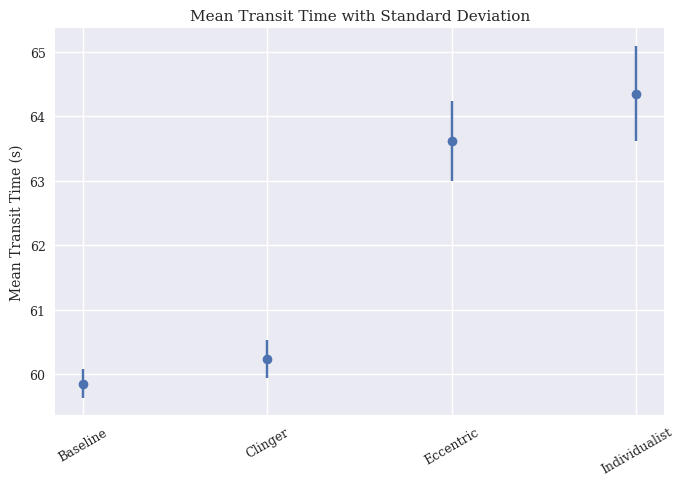

In [10]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- Style tuned for LaTeX ---
plt.style.use("seaborn-v0_8")

plt.rcParams.update({
    "font.family": "serif",        # LaTeX-like font
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# --- Ensure output folder exists ---
os.makedirs("figures", exist_ok=True)

# --- Create figure ---
fig, ax = plt.subplots(figsize=(7,5))

ax.errorbar(
    table_stats["Behavior"],
    table_stats["MeanTransit_mean"],
    yerr=table_stats["MeanTransit_std"],
    fmt='o',
    capsize=0
)

ax.set_ylabel("Mean Transit Time (s)")
ax.set_title("Mean Transit Time with Standard Deviation")

ax.grid(True)

# rotate labels if needed (often helpful for categories)
plt.xticks(rotation=30)

plt.tight_layout()

# --- Save as vector PDF (perfect for LaTeX) ---
fig.savefig("../figures/MeanTransit.pdf", bbox_inches='tight')
plt.show()

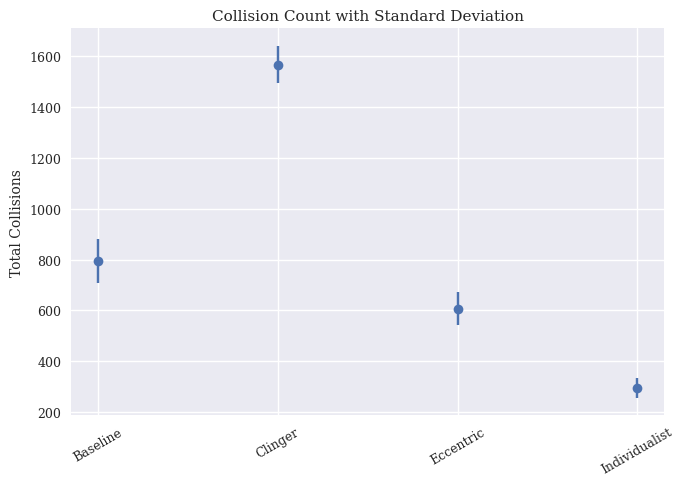

In [16]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- Style tuned for LaTeX ---
plt.style.use("seaborn-v0_8")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# --- Ensure output folder exists ---
os.makedirs("../figures", exist_ok=True)

# --- Create figure ---
fig, ax = plt.subplots(figsize=(7,5))

ax.errorbar(
    table_stats["Behavior"],
    table_stats["Collisions_mean"],
    yerr=table_stats["Collisions_std"],
    fmt='o',
    capsize=0
)

ax.set_ylabel("Total Collisions")
ax.set_title("Collision Count with Standard Deviation")

ax.grid(True)

# rotate labels if needed
plt.xticks(rotation=30)

plt.tight_layout()

# --- Save as vector PDF ---
fig.savefig("../figures/Collisionss.pdf", bbox_inches='tight')

plt.show()

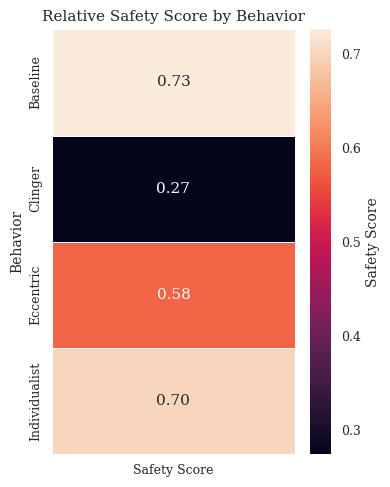

In [18]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- Style tuned for LaTeX ---
plt.style.use("seaborn-v0_8")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# --- Ensure output folder exists ---
os.makedirs("../figures", exist_ok=True)

# --- Copy data ---
heatmap_data = table_stats.copy()

# Normalize values: lower is better
heatmap_data["Collisions_norm"] = (
    heatmap_data["Collisions_mean"] - heatmap_data["Collisions_mean"].min()
) / (
    heatmap_data["Collisions_mean"].max() - heatmap_data["Collisions_mean"].min()
)

heatmap_data["Transit_norm"] = (
    heatmap_data["MeanTransit_mean"] - heatmap_data["MeanTransit_mean"].min()
) / (
    heatmap_data["MeanTransit_mean"].max() - heatmap_data["MeanTransit_mean"].min()
)

# Safety score:
# collisions matter more than transit time
heatmap_data["Safety Score"] = 1 - (
    0.7 * heatmap_data["Collisions_norm"] +
    0.3 * heatmap_data["Transit_norm"]
)

# Prepare heatmap table
heatmap_matrix = heatmap_data.set_index("Behavior")[["Safety Score"]]

# --- Create figure ---
fig, ax = plt.subplots(figsize=(4, 5))

sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Safety Score"},
    ax=ax
)

ax.set_title("Relative Safety Score by Behavior")
ax.set_xlabel("")
ax.set_ylabel("Behavior")

plt.tight_layout()

# --- Save as vector PDF ---
fig.savefig("../figures/SafetyHeatmap.pdf", bbox_inches="tight")

plt.show()